# Duelo de Modelos - Titanic
Este projeto tem como objetivo desenvolver e comparar modelos de Machine Learning para prever a sobrevivência dos passageiros do Titanic, utilizando a competição disponibilizada pelo Kaggle como ambiente de aplicação prática.

O projeto será dividido em duas etapas principais. A primeira consiste na análise exploratória dos dados, buscando compreender a estrutura da base, suas características, possíveis inconsistências e padrões relevantes. A segunda será dedicada ao desenvolvimento, otimização e comparação dos modelos de classificação, culminando na geração de previsões para submissão ao Kaggle.

O modelo principal será definido durante o desenvolvimento do projeto, considerando os resultados obtidos nos experimentos e a aplicação de técnicas como pré-processamento, balanceamento, padronização, validação cruzada e otimização de hiperparâmetros.

A análise exploratória realizada neste notebook servirá como base para as decisões tomadas na etapa de modelagem.

# Bibliotecas - 

In [167]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [168]:
# Paleta de cores do projeto
VERMELHO_ESCURO = '#8B1E1E'
VERMELHO = '#B23A3A'
VINHO = '#5C1515'
PRETO = '#1C1C1C'
CINZA = "#727272"
BRANCO = '#FFFFFF'

# 1. Conhecimento das bases

In [169]:
train = pd.read_csv('../data/train.csv')
test = pd.read_csv('../data/test.csv')
gender_submission = pd.read_csv('../data/gender_submission.csv')

# 2. Estrutura dos dados

In [170]:
# Dimensões das bases
print('Train:', train.shape)
print('Test:', test.shape)
print('Gender Submission:', gender_submission.shape)

# Primeiras linhas
display(train.head())
display(test.head())
display(gender_submission.head())

# Tipos das variáveis
train.info()

Train: (891, 12)
Test: (418, 11)
Gender Submission: (418, 2)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S


,PassengerId,Survived
0,892,0
1,893,1
2,894,0
3,895,0
4,896,1


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


# 3. Qualidade dos dados 

In [171]:
# Valores ausentes
print(train.isnull().sum())
print(test.isnull().sum())

# Duplicidades
print('Duplicatas no train:', train.duplicated().sum())
print('Duplicatas no test:', test.duplicated().sum())

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64
PassengerId      0
Pclass           0
Name             0
Sex              0
Age             86
SibSp            0
Parch            0
Ticket           0
Fare             1
Cabin          327
Embarked         0
dtype: int64
Duplicatas no train: 0
Duplicatas no test: 0


Os dados apresentam valores ausentes nas variáveis Age, Cabin, Embarked e Fare. Não foram identificadas duplicidades nas bases. O tratamento dos valores ausentes será realizado posteriormente, durante a preparação dos dados para modelagem.

# 4. Análise da variável-alvo

In [172]:
print(train['Survived'].value_counts())
print(train['Survived'].value_counts(normalize=True))

Survived
0    549
1    342
Name: count, dtype: int64
Survived
0    0.616162
1    0.383838
Name: proportion, dtype: float64


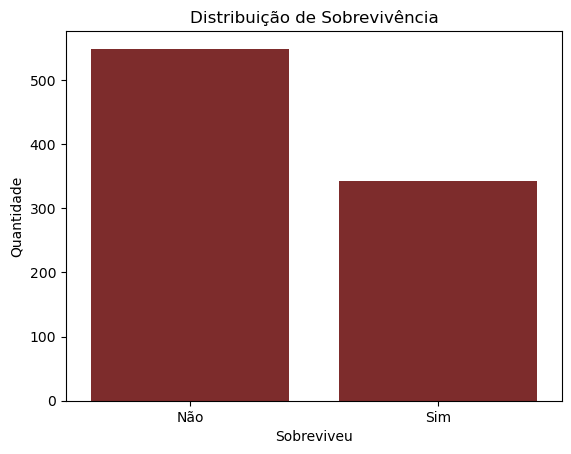

In [173]:
# Distribuição de sobrevivência

sns.countplot(
    data=train,
    x='Survived',
    color=VERMELHO_ESCURO
)

plt.title('Distribuição de Sobrevivência')
plt.xlabel('Sobreviveu')
plt.ylabel('Quantidade')
plt.xticks([0, 1], ['Não', 'Sim'])

plt.show()

# 5. Análise das principais variáveis
## 5.1 Sexo x Sobrevivência

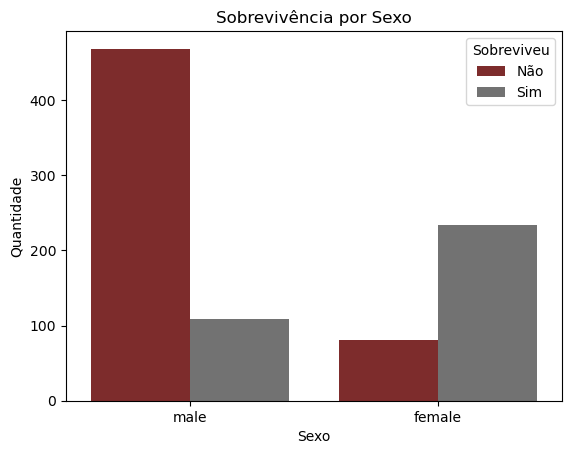

In [174]:
# Sobrevivência por sexo

sns.countplot(
    data=train,
    x='Sex',
    hue='Survived',
    palette=[VERMELHO_ESCURO, CINZA]
)

plt.title('Sobrevivência por Sexo')
plt.xlabel('Sexo')
plt.ylabel('Quantidade')
plt.legend(title='Sobreviveu', labels=['Não', 'Sim'])

plt.show()

A distribuição mostra uma diferença clara na sobrevivência entre os sexos. Apesar de serem maioria entre os passageiros, os homens apresentaram uma quantidade muito maior de mortes, enquanto as mulheres, mesmo sendo minoria, apresentaram mais sobreviventes do que não sobreviventes. Portanto, Sex aparenta ser uma variável relevante para explicar Survived e deverá ser considerada posteriormente na modelagem.

## 5.2 Classe x Sobrevivência

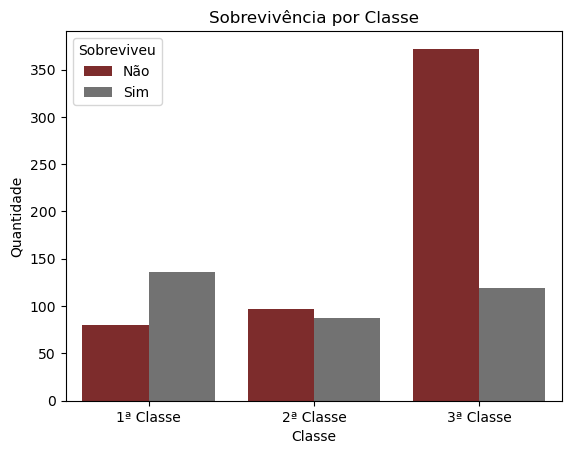

In [175]:
# Sobrevivência por classe

sns.countplot(
    data=train,
    x='Pclass',
    hue='Survived',
    palette=[VERMELHO_ESCURO, CINZA]
)

plt.title('Sobrevivência por Classe')
plt.xlabel('Classe')
plt.ylabel('Quantidade')
plt.xticks([0, 1, 2], ['1ª Classe', '2ª Classe', '3ª Classe'])
plt.legend(title='Sobreviveu', labels=['Não', 'Sim'])

plt.show()

A classe apresenta diferenças evidentes na distribuição de sobrevivência. A 1ª classe possui maior quantidade de sobreviventes que de não sobreviventes, a 2ª classe apresenta valores próximos entre as duas categorias, enquanto a 3ª classe concentra a maior quantidade de passageiros e de mortes.

## 5.3 Idade x Sobrevivência

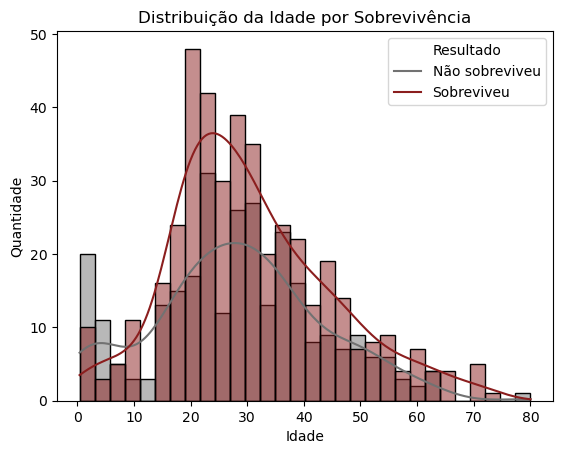

In [176]:
# Distribuição da idade por sobrevivência

sns.histplot(
    data=train,
    x='Age',
    hue='Survived',
    bins=30,
    kde=True,
    palette=[VERMELHO_ESCURO, CINZA]
)

plt.title('Distribuição da Idade por Sobrevivência')
plt.xlabel('Idade')
plt.ylabel('Quantidade')

plt.legend(
    title='Resultado',
    labels=['Não sobreviveu', 'Sobreviveu']
)

plt.show()

A distribuição de idade apresenta bastante sobreposição entre sobreviventes e não sobreviventes, embora algumas diferenças possam ser observadas principalmente entre crianças e adultos. A variável Age pode possuir alguma relação com a sobrevivência, mas visualmente essa relação parece menos evidente que as observadas em Sex e Pclass.

# 6. Visualizações
## 6.1. Sexo x Classe x Sobrevivência

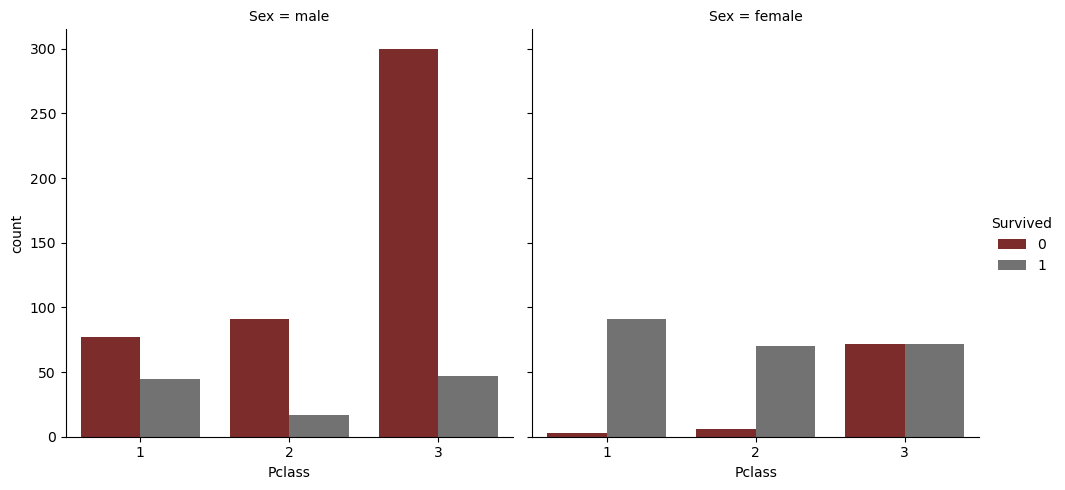

In [177]:
# Sexo, classe e sobrevivência

sns.catplot(
    data=train,
    x='Pclass',
    hue='Survived',
    col='Sex',
    kind='count',
    palette=[VERMELHO_ESCURO, CINZA]
)

plt.show()

A combinação entre Sex e Pclass evidencia diferenças importantes na distribuição de sobrevivência, especialmente entre homens e mulheres das diferentes classes.

## 6.2 Distribuição por tarifa (Fare)

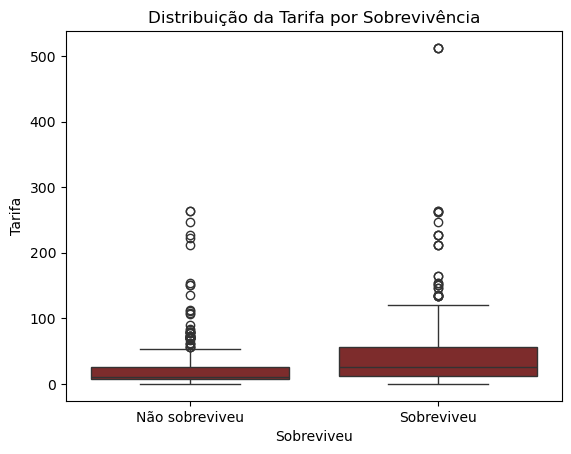

In [178]:
# Distribuição da tarifa por sobrevivência

sns.boxplot(
    data=train,
    x='Survived',
    y='Fare',
    color=VERMELHO_ESCURO
)

plt.title('Distribuição da Tarifa por Sobrevivência')
plt.xlabel('Sobreviveu')
plt.ylabel('Tarifa')
plt.xticks([0, 1], ['Não sobreviveu', 'Sobreviveu'])

plt.show()

Passageiros que pagaram tarifas mais elevadas apresentaram, nos dados, maior concentração entre os sobreviventes, sugerindo que Fare pode ser uma variável relevante para a modelagem.

## 6.3 Matriz de correlação

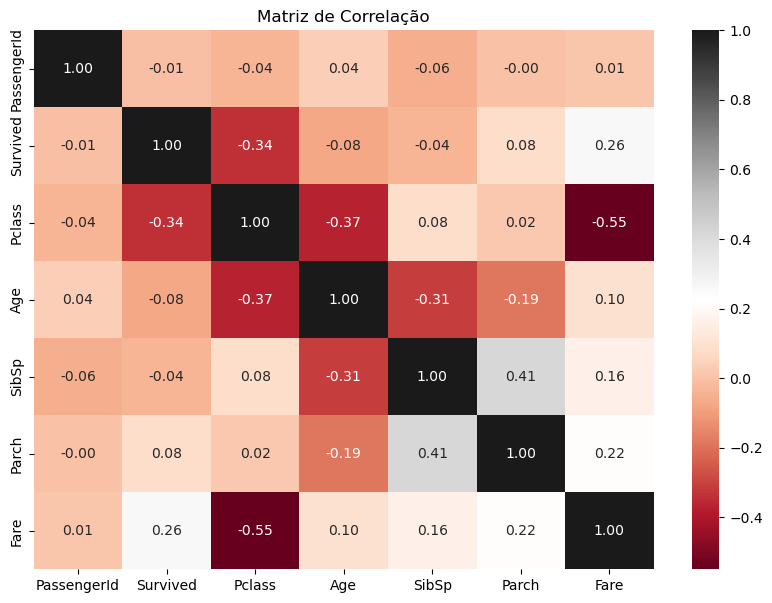

In [179]:
# Matriz de correlação

plt.figure(figsize=(10, 7))

sns.heatmap(
    train.corr(numeric_only=True),
    annot=True,
    cmap='RdGy',
    fmt='.2f'
)

plt.title('Matriz de Correlação')
plt.show()

Pclass apresenta a maior correlação, em módulo, com Survived entre as variáveis analisadas, enquanto Fare também apresenta uma relação perceptível. As demais variáveis possuem correlações fracas com a variável-alvo.

## 6.4 Taxa por sobrevivência por classe

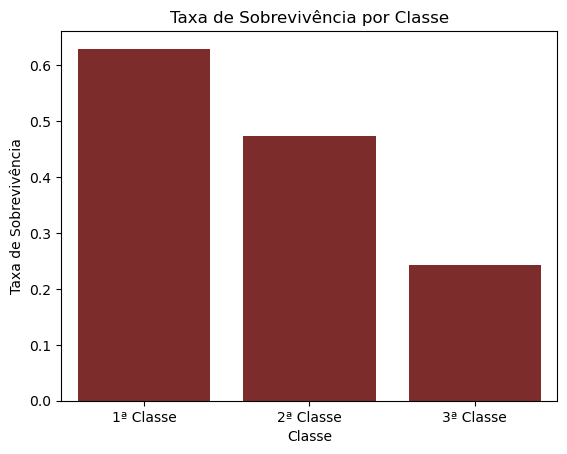

In [180]:
# Taxa de sobrevivência por classe

taxa_classe = train.groupby('Pclass')['Survived'].mean().reset_index()

sns.barplot(
    data=taxa_classe,
    x='Pclass',
    y='Survived',
    color=VERMELHO_ESCURO
)

plt.title('Taxa de Sobrevivência por Classe')
plt.xlabel('Classe')
plt.ylabel('Taxa de Sobrevivência')
plt.xticks([0, 1, 2], ['1ª Classe', '2ª Classe', '3ª Classe'])

plt.show()

A taxa de sobrevivência diminui conforme aumenta o número da classe, reforçando Pclass como uma variável relevante para explicar Survived.

## 6.5 Sobrevivência por local de embarque (Embarked)

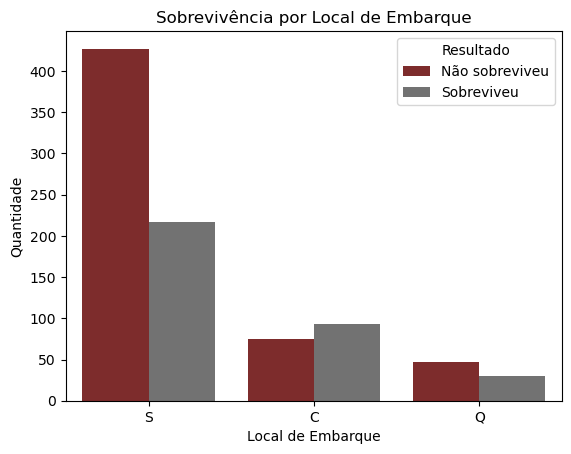

In [181]:
# Sobrevivência por local de embarque

sns.countplot(
    data=train,
    x='Embarked',
    hue='Survived',
    palette=[VERMELHO_ESCURO, CINZA]
)

plt.title('Sobrevivência por Local de Embarque')
plt.xlabel('Local de Embarque')
plt.ylabel('Quantidade')
plt.legend(
    title='Resultado',
    labels=['Não sobreviveu', 'Sobreviveu']
)

plt.show()

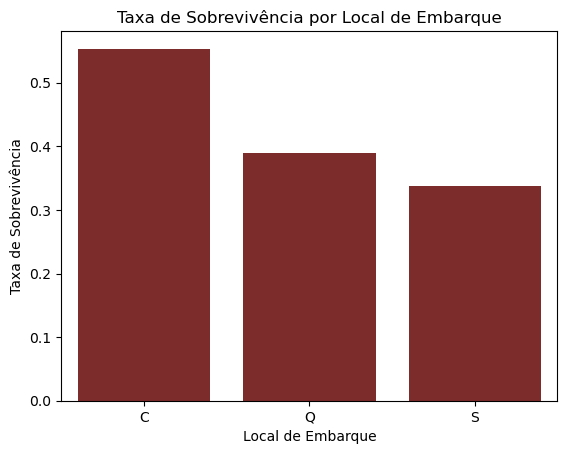

In [182]:
taxa_embarque = train.groupby('Embarked')['Survived'].mean().reset_index()

sns.barplot(
    data=taxa_embarque,
    x='Embarked',
    y='Survived',
    color=VERMELHO_ESCURO
)

plt.title('Taxa de Sobrevivência por Local de Embarque')
plt.xlabel('Local de Embarque')
plt.ylabel('Taxa de Sobrevivência')
plt.show()

O local de embarque apresenta diferenças na distribuição de sobrevivência, com destaque para C, que possui maior proporção de sobreviventes, enquanto S concentra a maior quantidade de passageiros e mortes.

# 7. Insights finais
A análise exploratória indica que Sex e Pclass apresentam as diferenças mais evidentes na distribuição de sobrevivência. A combinação dessas variáveis evidencia padrões ainda mais claros, principalmente entre homens e mulheres de diferentes classes.

Fare também apresenta diferenças entre sobreviventes e não sobreviventes, com tarifas mais elevadas concentradas em maior proporção entre os sobreviventes. A matriz de correlação reforça Pclass e Fare como as variáveis numéricas com maior relação com Survived.

Age apresenta maior sobreposição entre os grupos, enquanto Embarked demonstra diferenças nas taxas de sobrevivência entre os locais de embarque. A análise também identificou valores ausentes em algumas variáveis, que deverão ser tratados posteriormente na preparação para a modelagem.

Conclusão: os resultados exploratórios fornecem indícios de que características como Sex, Pclass e Fare podem contribuir para a previsão de sobrevivência, mas a relevância efetiva dessas variáveis deverá ser avaliada durante a etapa de modelagem e no duelo entre os algoritmos. 